In [1]:
# package(s) used for creating and geo-locating the graph
import networkx as nx
from pyproj import Geod
from shapely.geometry import Point, LineString
from opentnsim import graph

# package(s) related to the hydrodynamics and tidal windows
import xarray as xr

# load OpenTNSim modules
from opentnsim.core import Identifiable, Movable 
from opentnsim.core.vessel_properties import VesselProperties
from opentnsim.graph import HasMultiDiGraph
from opentnsim.vessel_traffic_service import VesselTrafficService
from opentnsim.port.mixins.port import IsPort, HasPortAccess
from opentnsim.port.mixins.terminal import IsTerminal, HasTerminal
from opentnsim.port.mixins.berth import IsJetty, IsQuay
from opentnsim.port.mixins.anchorage_area import IsAnchorage, PassesAnchorage
from opentnsim.port.mixins import tidal_accessibility
from opentnsim.port.mixins.tidal_accessibility import HasDraughtRestrictions
from opentnsim.port.rule_constructor import vessel_characteristics, vessel_direction, vessel_type
from opentnsim.port.tidal_window_constructor import vessel_specifications, \
                                                    vertical_tidal_window_specifications, \
                                                    vertical_tidal_window_input, \
                                                    horizontal_tidal_window_specifications, \
                                                    horizontal_tidal_window_method, \
                                                    horizontal_tidal_window_input, \
                                                    tidal_period, \
                                                    accessibility, \
                                                    NetworkProperties

# package(s) related to the simulation (creating the vessel, running the simulation)
import datetime
import simpy
import opentnsim

# package(s) needed for inspecting the output
import pandas as pd
import numpy as np

# package(s) for plotting
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates


import os


print("This notebook is executed with OpenTNSim version {}".format(opentnsim.__version__))

This notebook is executed with OpenTNSim version 1.3.7


In [2]:
%load_ext autoreload
%autoreload 2

#### Define input
graph

In [3]:
number_of_nodes = 11

vessel

In [4]:
vessel_length = 400 # 200m (ever ace, grote container schip in haven rotterdam) 
vessel_beam = 61.5 # 40 m (ever ace, grote container schip in haven rotterdam) 
vessel_draught = 14.2  #14.2 m (ever ace, grote container schip in haven rotterdam) 
vessel_speed = 4.5 #m/s

infrastructure

In [5]:
waterway_length = 11350 #meters #25000 euro en maasgeul = 57 km (eurogeul is 45,65 km) (maasgeul = 11,35 km) 
waterway_depth = 23.2 #meters #15 m (NGD: nautical guaranteed depth = MBL: maintained bed level) #eurogeul neemt stapgewijs af van 24,2 -> 23,7 m over de 57 km. nautische gegarandeerde diepte maasgeul is 23,20 m 

harbour_basin_depth = 22.83  # binnengebied Maasmond 
anchorage_area_depth = 24.2

tide

In [6]:
tidal_period = 12.5 #hours
# tidal_range_sea = 1.8 #meters (2.0m)
tidal_range_sea = [1.0, 2.0, 4.0, 8.0]
tidal_propagation_speed = np.sqrt(9.81*waterway_depth) #meters per second (np.sqkart(grav_acc*waterway_depth)), grav_acc=9.81
tidal_amplication = 0.8 #amplification factor


tidal restrictions

In [7]:
#percentage of the draught as UKC (10% of draught is common)
ukc_percentage = 10.0 * np.ones(number_of_nodes) #% of draught 

#static value as UKC (0.5 m is common, but not in combination with ukc_percentage)
ukc_static = 0.0 * np.ones(number_of_nodes) #meters

#freshwater allowance as percentage of draught as additional UKC: saltwater at sea (no sinkage), fresher water in port (5% extra sinkage common)
fwa = 0.0 * np.ones(number_of_nodes) #% of draught 

#### 0. Create environment

In [8]:
# set simulation time
simulation_start = datetime.datetime(2024, 1, 1, 0, 0, 0)
simulation_stop = datetime.datetime(2024, 1, 8, 0, 0, 0)

# create time series aligned with simulation time
timestep = pd.Timedelta(minutes=5)
time_series = pd.date_range(simulation_start,simulation_stop,freq=timestep)

env = simpy.Environment(initial_time=simulation_start.timestamp())
env.simulation_start = simulation_start
env.simulation_stop = simulation_stop
env.epoch = simulation_start

#### 1. Create graph
Next we create a network (a graph) along which the vessel can move. For this case we create a single edge of 100 km exactly.

In [9]:
# initialize geodetic calculator with WGS84 ellipsoid
geod = Geod(ellps="WGS84")

In [10]:
# starting point (longitude, latitude)
coordinates_sea = (0,0)

# compute the other point 100 km East from Point 0
coordinates_waterway = {}
coordinates_waterway[0] = coordinates_sea
coordinates_previous_node = coordinates_sea
for node in range(number_of_nodes-1):
    coordinates_node = geod.fwd(coordinates_previous_node[0], coordinates_previous_node[1], 90 ,waterway_length/(number_of_nodes-1)) #east from previous node
    coordinates_waterway[node+1] = (coordinates_node[0],coordinates_node[1])
    coordinates_previous_node = coordinates_node

In [11]:
# create list of edges
edges = []
for node_start,node_stop in zip(range(0,number_of_nodes-1),range(1,number_of_nodes)):
    edges.append((node_start,node_stop))
    edges.append((node_stop,node_start))

In [12]:
# create a directed graph
FG = nx.DiGraph()

# add nodes
for name, coordinate in coordinates_waterway.items():
    FG.add_node(name, geometry=Point(coordinate[0], coordinate[1]))

# add edges
for edge in edges:
    waterway_geometry = LineString([Point(coordinates_waterway[edge[0]]),Point(coordinates_waterway[edge[1]])])
    FG.add_edge(edge[0], edge[1], geometry=waterway_geometry, weight=1, length_m=waterway_length/(number_of_nodes-1))

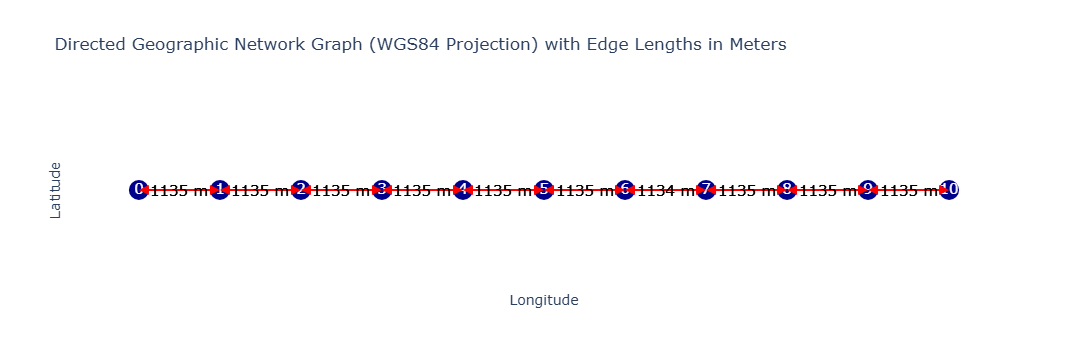

In [13]:
opentnsim.graph.plot_graph(FG)

In [14]:
# add graph to environment
env.graph = FG

#### 1a. Adding a Vessel Traffic Service (VTS)

In [15]:
simulation_start = time_series[0]
simulation_stop  = time_series[-1]

In [16]:
# create empty hydrodynamic dataset
hydrodynamic_data = xr.Dataset()

In [17]:
#test rotterdam

path = os.getcwd()
data_path = os.path.join(path, "data", "Port_accessibility")

In [18]:
df = pd.read_csv(os.path.join(data_path,"rotterdam_data.csv"), delimiter=';', encoding='ISO-8859-1', on_bad_lines='skip')

In [19]:
df['TIME'] = df['WAARNEMINGDATUM'] + ' ' + df['WAARNEMINGTIJD (MET/CET)']
df['TIME'] = pd.to_datetime(df['TIME'], format = "%d-%m-%Y %H:%M:%S")
df = df[['TIME','MEETPUNT_IDENTIFICATIE','NUMERIEKEWAARDE']]
df = df.rename(columns={'MEETPUNT_IDENTIFICATIE':'Location','NUMERIEKEWAARDE':'Water level'})
df = df.set_index('TIME')

In [20]:
df['Water level'] = df['Water level'].apply(lambda x: x if x < 200 else np.nan)
df['Water level'] = df['Water level'].interpolate()

In [21]:
botlek_data = df[df['Location'] == 'Geulhaven Radarpost 10']
HvH_data = df[df['Location'] == 'Hoek van Holland']
Moerdijk_data = df[df['Location'] == 'Moerdijk']
Rotterdam_data = df[df['Location'] == 'Rotterdam']
Rotterdam_data["Water level"] = Rotterdam_data["Water level"] / 100.0   # cm -> m
botlek_data.pop('Location')
HvH_data.pop('Location')
Moerdijk_data.pop('Location')
Rotterdam_data.pop('Location');

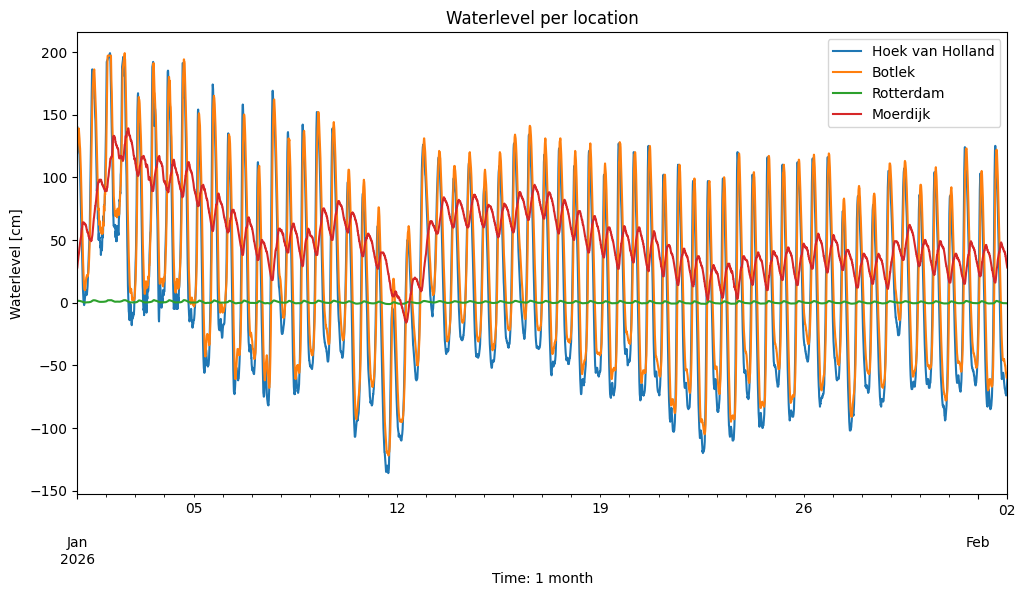

In [22]:
fig,ax = plt.subplots(figsize=[12,6])
HvH_data.plot(ax=ax, label='Hoek van Holland')
botlek_data.plot(ax=ax, label='Botlek')
Rotterdam_data.plot(ax=ax, label='Rotterdam')
Moerdijk_data.plot(ax=ax, label='Moerdijk');

ax.set_xlabel('Time: 1 month')
ax.set_ylabel('Waterlevel [cm]')
ax.set_title('Waterlevel per location')

ax.legend(['Hoek van Holland', 'Botlek', 'Rotterdam', 'Moerdijk'])
plt.show()

#rond NAP? 

In [23]:
# #test meerder tidal ranges

# water_level_scenarios={} 

# for tr in tidal_range_sea:
#     water_level_data = np.zeros((number_of_nodes,len(time_series)))
    
#     for node in FG.nodes:
#         route_to_sea = nx.dijkstra_path(FG,0,node)
#         distance_to_sea = 0.
        
#     for node_start,node_stop in zip(route_to_sea[:-1],route_to_sea[1:]):
#         distance_to_sea += FG.edges[node_start,node_stop]['length_m']

#     amplification_factor = 1 - 0.2*(distance_to_sea/waterway_length)
#     phase_shift = pd.Timedelta(seconds=distance_to_sea/tidal_propagation_speed)
    
#     tidal_amplitude = amplification_factor*(tr/2)
#     tidal_water_level = tidal_amplitude*np.sin(2*np.pi*((time_series-simulation_start-phase_shift)/(12.5*pd.Timedelta(hours=1))))
#     water_level_data[node] = tidal_water_level
    
# water_level_data_array = xr.DataArray(data=water_level_data,coords={'STATION':FG.nodes,'TIME':time_series})

# water_level_scenarios[tr] = water_level_data_array

In [24]:
# water_level_data = np.zeros((number_of_nodes,len(time_series)))
# for node in FG.nodes:
#     route_to_sea = nx.dijkstra_path(FG,0,node)
#     distance_to_sea = 0.
#     for node_start,node_stop in zip(route_to_sea[:-1],route_to_sea[1:]):
#         distance_to_sea += FG.edges[node_start,node_stop]['length_m']

#     amplification_factor = 1 - 0.2*(distance_to_sea/waterway_length)
#     phase_shift = pd.Timedelta(seconds=distance_to_sea/tidal_propagation_speed)
#     tidal_amplitude = amplification_factor*(tidal_range_sea/2)
#     tidal_water_level = tidal_amplitude*np.sin(2*np.pi*((time_series-simulation_start-phase_shift)/(12.5*pd.Timedelta(hours=1))))
#     water_level_data[node] = tidal_water_level
# water_level_data_array = xr.DataArray(data=water_level_data,coords={'STATION':FG.nodes,'TIME':time_series})

In [25]:
time_series = Rotterdam_data.index
simulation_start = time_series[0]
simulation_stop  = time_series[-1]

In [26]:
# wl_rt = Rotterdam_data["Water level"].copy()

# water_level_data = np.tile(wl_rt.values, (number_of_nodes, 1))

# water_level_data_array = xr.DataArray(
#     data=water_level_data,
#     coords={"STATION": list(FG.nodes), "TIME": time_series},
#     dims=("STATION", "TIME")
# )

In [27]:
# Neem water levels als numpy arrays
wl_hvh = HvH_data["Water level"].values
wl_geul = botlek_data["Water level"].values

# Zorg dat time_series gelijk is aan de data-index
time_series = HvH_data.index

water_level_data = np.zeros((number_of_nodes, len(time_series)))

for node in range(number_of_nodes):
    alpha = node / (number_of_nodes - 1)  # 0 bij node 0, 1 bij node 10
    
    # lineaire interpolatie tussen Hoek van Holland en Geulhaven
    water_level_data[node, :] = (1 - alpha) * wl_hvh + alpha * wl_geul

water_level_data_array = xr.DataArray(
    data=water_level_data,
    coords={"STATION": list(FG.nodes), "TIME": time_series},
    dims=("STATION", "TIME")
)

In [28]:
# # 1) selecteer alleen Rotterdam water levels als Series
# wl_rt = Rotterdam_data["Water level"].copy()

# # 2) match met time_series van de simulatie (resample + interpolate naar simulatie-grid)
# #    (hier neem ik aan dat time_series een vaste timestep heeft; dit werkt ook als die niet exact gelijk is)
# wl_rt = wl_rt.reindex(pd.DatetimeIndex(time_series)).interpolate()

# # 3) maak DataArray: zelfde waterstand voor alle nodes (eerst simpel)
# water_level_data = np.tile(wl_rt.values, (number_of_nodes, 1))

# water_level_data_array = xr.DataArray(
#     data=water_level_data,
#     coords={"STATION": list(FG.nodes), "TIME": pd.DatetimeIndex(time_series)},
#     dims=("STATION", "TIME")
# )

In [29]:
MBL_data = waterway_depth*np.ones([number_of_nodes,len(time_series)])
MBL_data_array = xr.DataArray(data=MBL_data,coords={'STATION':FG.nodes,'TIME':time_series})

In [30]:
hydrodynamic_data['Water level'] = water_level_data_array
hydrodynamic_data['MBL'] = MBL_data_array

In [31]:
print(water_level_data_array.shape)
print(np.isnan(water_level_data_array.values).sum(), "NaNs")
print(water_level_data_array.min().values, water_level_data_array.max().values)

(11, 4609)
0 NaNs
-136.0 199.0


In [32]:
print(df.index.min(), df.index.max(), len(df))
print(Rotterdam_data.index.min(), Rotterdam_data.index.max(), len(Rotterdam_data))
print(Rotterdam_data.head(3))
print(Rotterdam_data.tail(3))

2026-01-01 00:00:00 2026-02-02 00:00:00 18436
2026-01-01 00:00:00 2026-02-02 00:00:00 4609
                     Water level
TIME                            
2026-01-01 00:00:00         0.98
2026-01-01 00:10:00         1.13
2026-01-01 00:20:00         1.25
                     Water level
TIME                            
2026-02-01 23:40:00        -0.53
2026-02-01 23:50:00        -0.54
2026-02-02 00:00:00        -0.56


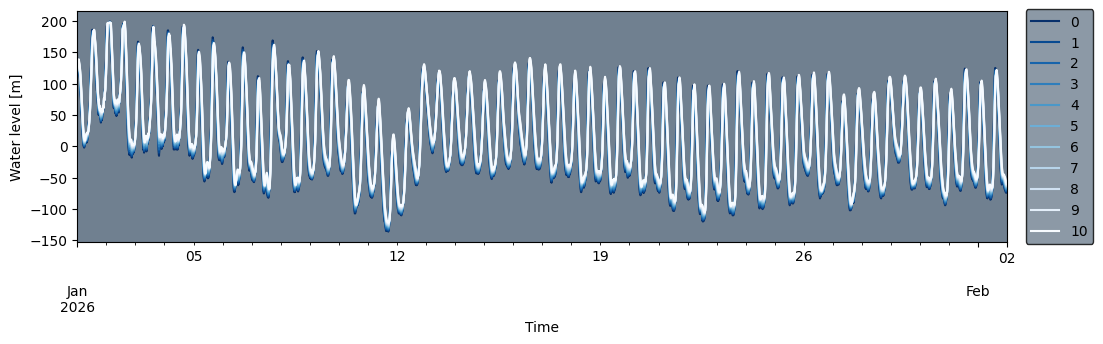

In [33]:
fig,ax = plt.subplots(figsize=[12,3])
ax.set_facecolor('slategray')
pd.DataFrame(hydrodynamic_data['Water level'].T,index=hydrodynamic_data['TIME']).plot(ax=ax,cmap='Blues_r')
ax.set_xlabel('Time')
ax.set_ylabel('Water level [m]')
ax.set_xlim(time_series[0],time_series[-1])
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.legend(loc='upper right',frameon=True,bbox_to_anchor=[1.1,1.0375],facecolor='slategray',edgecolor='k');

In [34]:
print(time_series[0], time_series[-1], len(time_series))
print(hydrodynamic_data['Water level'].dims)
print(np.isnan(hydrodynamic_data['Water level'].values).sum())

2026-01-01 00:00:00 2026-02-02 00:00:00 4609
('STATION', 'TIME')
0


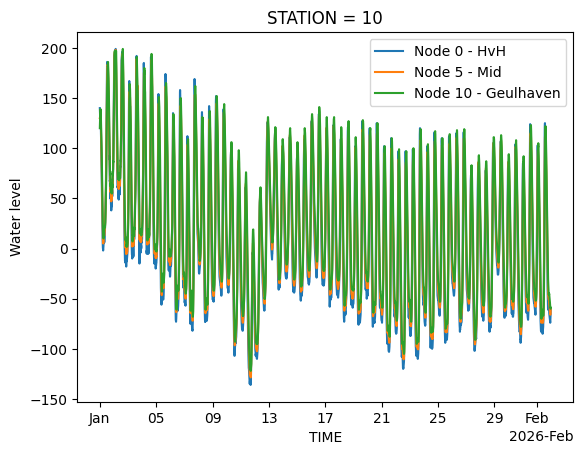

In [35]:
hydrodynamic_data['Water level'].sel(STATION=0).plot(label="Node 0 - HvH")
hydrodynamic_data['Water level'].sel(STATION=5).plot(label="Node 5 - Mid")
hydrodynamic_data['Water level'].sel(STATION=10).plot(label="Node 10 - Geulhaven")
plt.legend()
plt.show()

In [36]:
print(np.allclose(
    hydrodynamic_data['Water level'].sel(STATION=0).values,
    hydrodynamic_data['Water level'].sel(STATION=10).values
))

print(np.allclose(
    hydrodynamic_data['Water level'].sel(STATION=0).values,
    hydrodynamic_data['Water level'].sel(STATION=5).values
))


False
False


In [37]:
a = hydrodynamic_data["Water level"].sel(STATION=0).values
b = hydrodynamic_data["Water level"].sel(STATION=10).values

print("max abs diff 0-10:", float(np.max(np.abs(a-b))))
print("mean abs diff 0-10:", float(np.mean(np.abs(a-b))))

max abs diff 0-10: 76.0
mean abs diff 0-10: 22.778021262746798


In [38]:
vessel_traffic_service = VesselTrafficService(hydrodynamic_data = hydrodynamic_data)
env.vessel_traffic_service = vessel_traffic_service


In [39]:
ukc_p = ukc_percentage/100 #percentage of the UKC (10% of draught is common)
ukc_s = ukc_static #static value of the UKC
fwa = fwa/100 #freshwater allowance as percentage of UKC: saltwater at sea (no sinkage), fresher water in port (5% extra sinkage)

network_properties = NetworkProperties()
for index,node in enumerate(FG.nodes):
    FG.nodes[node]['Vertical tidal restriction'] = {}
    vertical_tidal_window_inputs = []

    vessel_specification = vessel_specifications({vessel_characteristics.min_ge_Draught: 0.0},'x',vessel_direction.inbound)
    window_specification = vertical_tidal_window_specifications(ukc_s = ukc_s[index],
                                                                ukc_p = ukc_p[index],
                                                                fwa = fwa[index],)
    
    vertical_tidal_window_inputs.append(vertical_tidal_window_input(vessel_specifications = vessel_specification,
                                                                    window_specifications = window_specification))

    network_properties.append_vertical_tidal_restriction_to_network(env.graph,node,vertical_tidal_window_inputs)
    

#### 1b. Adding Port Infrastructure

In [40]:
port = IsPort(env=env, name = "Port", port_entry_nodes=[0])

In [41]:
anchorage = IsAnchorage(env=env, capacity=20, name = 'Anchorage', node = 0, depth=anchorage_area_depth, geometry=env.graph.nodes[0]['geometry'], port = port)

In [42]:
jetty = IsJetty(env=env,length=400, depth=harbour_basin_depth, name='Jetty',node=10)
terminal = IsTerminal(env=env, name = 'Terminal', berths=[jetty], port = port)

#### 2. Create agents

In [43]:
# make your preferred Vessel class out of available mix-ins.
Vessel = type(
    "Vessel", 
    (HasPortAccess,
     HasTerminal,
     PassesAnchorage,
     HasDraughtRestrictions,
     HasMultiDiGraph,
     Identifiable, # allows to give the object a name and a random ID,
     Movable,      # allows the object to move, with a fixed speed, while logging this activity
     VesselProperties,
    ), 
    {}
)

In [44]:
def mission(env, vessel):
    """
    Method that defines the mission of the vessel. 
    
    In this case: 
        keep moving along the path until its end point is reached
    """
    yield from vessel.move()

In [47]:
# create vessel from a dict 

vessel_loading_factor = 0

path = nx.dijkstra_path(env.graph, 0, 10)
data_vessel = {
    "env": env,                                       # needed for simpy simulation
    "name": "Vessel 1",                               # required by Identifiable
    "geometry": env.graph.nodes[path[0]]['geometry'], # required by Locatable
    "route": path,                                    # required by Routeable
    "v": vessel_speed,                                # required by Movable, 1 m/s to check if the distance is covered in the expected time
    "bound": 'inbound',
    "terminal": terminal,
    "berthing_time":15, #minutes
    "loading_time": 12, #hours
    "deberthing_time":5, #minutes
    "next_destination":0,
    "type":"tanker",
    "L":vessel_length,
    "B":vessel_beam,
    "T":vessel_draught,
    "loading_factor":vessel_loading_factor,
}  # 

# create an instance of the Vessel class using the input dict data_vessel
vessel = Vessel(**data_vessel)

#test stuk
vessel.process_stop_time = pd.Timestamp(
    env.vessel_traffic_service.hydrodynamic_information.TIME.values[-1]
)

# start the simulation
vessel.mission = env.process(mission(env, vessel))


#### 3. Run simulation

In [48]:
# data = {
#     "Tide": [False, True, False, True, False, True, False, True, False, True],
#     "Terminal": [True] * 10,
# }

# index = [
#     "2024-01-01 00:00:00",
#     "2024-01-01 01:10:00",
#     "2024-01-01 03:25:00",
#     "2024-01-01 13:40:00",
#     "2024-01-01 15:55:00",
#     "2024-01-02 02:10:00",
#     "2024-01-02 04:25:00",
#     "2024-01-02 14:40:00",
#     "2024-01-02 16:55:00",
#     "2024-01-08 00:00:00",
# ]

# df = pd.DataFrame(data, index=pd.to_datetime(index))

In [49]:
# def get_waiting_time_reason(lst):
#     if not lst:
#         return ""  # No False columns
#     elif len(lst) == 1:
#         return lst[0]
#     else:
#         return ", ".join(lst[:-1]) + " and " + lst[-1]

# port_availability_df = df
# port_availability_df['Reason'] = port_availability_df.apply(lambda row: get_waiting_time_reason(list(row.index[~row.values])),axis=1)

In [50]:
hydro_time = env.vessel_traffic_service.hydrodynamic_information.TIME.values
print("Hydro length:", len(hydro_time))
print("Hydro start:", hydro_time[0])
print("Hydro end:", hydro_time[-1])

Hydro length: 4609
Hydro start: 2026-01-01T00:00:00.000000000
Hydro end: 2026-02-02T00:00:00.000000000


In [51]:
print("route:", vessel.route[:3], "...", vessel.route[-3:])
print("sailing time (s):", env.vessel_traffic_service.provide_sailing_time(vessel.route))

route: [0, 1, 2] ... [8, 9, 10]


TypeError: VesselTrafficService.provide_sailing_time() missing 1 required positional argument: 'route'

In [52]:
env.run() 

IndexError: index 1 is out of bounds for axis 0 with size 0

In [ ]:
# def get_waiting_time_reason(lst):
#     if not lst:
#         return ""  # No False columns
#     elif len(lst) == 1:
#         return lst[0]
#     else:
#         return ", ".join(lst[:-1]) + " and " + lst[-1]

# port_availability_df = df
# port_availability_df['Reason'] = port_availability_df.apply(lambda row: get_waiting_time_reason(list(row.index[~row.values])),axis=1)

In [ ]:
# port_availability_df

#### 4. Inspect output
We can now inspect  the simulation output by inspecting the _vessel.logbook_. Note that the _Log_ mix-in was included when we added _Movable_. The _vessel.logbook_ keeps track of the moving activities of the vessel. For each discrete event OpenTNSim logs an event message, the start/stop time and the location. The _vessel.logbook_ is of type dict. For convenient inspection it can be loaded into a Pandas dataframe. 

In [ ]:
print(tidal_range_sea)
type(tidal_range_sea)
print("Running tidal range:", tr)

print("Range:", tr)
print("Max water level:", water_level_data_array.max().values)
print("Min water level:", water_level_data_array.min().values)
print("-" * 30)

print("MBL min/max:", float(hydrodynamic_data["MBL"].min()), float(hydrodynamic_data["MBL"].max()))
H = hydrodynamic_data["MBL"] + water_level_data_array
print("H min/max:", float(H.min()), float(H.max()))


In [ ]:
# load the logbook data into a dataframe
df = pd.DataFrame.from_dict(vessel.logbook)

print("'{}' logbook data:".format(vessel.name))  
print('')

display(df)

if not df.empty:
    trip_distance = opentnsim.graph.calculate_distance_along_path(FG, vessel.route)
    trip_duration = datetime.timedelta.total_seconds(vessel.logbook[-1]['Timestamp'] - vessel.logbook[0]['Timestamp'])
    print("'{}' travelled a distance of {:.1f} meters".format(vessel.name, trip_distance))
    print("'{}' took {:.1f} seconds to arrive at its destination".format(vessel.name, trip_duration)) 
    print("'{}' travelled at an average speed of {:.1f} meters per second".format(vessel.name, trip_distance/trip_duration))
else:
    print("The port was not accessible for vessel")
print('')
print('')

##### Logbook
We can also plot the tidal windows of the vessels, both the vertical, horizontal windows, and the resulting superimposed tidal windows.

In [ ]:
#Inbound trip
trip_index = 0
fig = vessel.plot_tidal_windows(trip_index=trip_index, plot_all = True)
fig

In [ ]:
#Outbound trip
trip_index = 1
fig = vessel.plot_tidal_windows(trip_index=trip_index, plot_all = True)
fig

In [ ]:
# load the logbook data into a dataframe
for vessel in env.vessels:
    df = pd.DataFrame.from_dict(vessel.logbook)
    
    print("'{}' logbook data:".format(vessel.name))  
    print('')
    
    display(df)
    
    if not df.empty:
        trip_distance = opentnsim.graph.calculate_distance_along_path(FG, vessel.route)
        trip_duration = datetime.timedelta.total_seconds(vessel.logbook[-1]['Timestamp'] - vessel.logbook[0]['Timestamp'])
        print("'{}' travelled a distance of {:.1f} meters".format(vessel.name, trip_distance))
        print("'{}' took {:.1f} seconds to arrive at its destination".format(vessel.name, trip_duration)) 
        print("'{}' travelled at an average speed of {:.1f} meters per second".format(vessel.name, trip_distance/trip_duration))
    else:
        print("The port was not accessible for vessel")
    print('')
    print


In [ ]:
# waterstand >- draught = ukc 
# dan kan er gebruik gemaakt worden van het kanaal. 
# waterstand is x en t afhankelijk. dus de waterstand veranderd over de tijd. hierdoor is de lengte van het kanaal ook van belang. 
# totol depth = water_level (x,t) + waterway_depth (x) (nu over elke edge hetzelfde)
# for tidal window use: total depth >- D+ukc (dit resulteerd in een percentage van de dag dat er gebruik gemaakt kan worden van het kanaal.) 
# misschien uitdrukken in % van de dag dat er gebruik gemaakt van kan worden-> dat indiceerd wachttijden en hoeveel schepen erdoor heen kunnen. 
#en ook de tijdstippen vermelden, die verschillen elke dag, maar misschien de tijdstippen dat er gebruik gemaakt kan worden van het kanaal voor een schip van een bepaalde diepgang over een weeek. 
# dan kan accessibility uitgedrukt worden in: accessibility(%) = aantal toegenagelijk uren per dag/ 24 uur * 100 = .. 
# accessibility fraction = tijd: total depth >/ (D + ukc) / total beschouwde tijd


#### test length vs amplitude


In [ ]:
# required depth 

required_depth = vessel_draught * (1 + ukc_p[0])  # d= T + uck_percentage(10%*T)
print(required_depth)

In [ ]:
# total waterdepth over space and time
H = hydrodynamic_data["MBL"] + hydrodynamic_data["Water level"] 


In [ ]:
# toegagnelijk per node

accessible_node = H >= required_depth

# kanaal is alleen toegankelijk als alle node voldoen aan de tidal window eis.  
accessible_channel = accessible_node.all(dim="STATION")


In [ ]:
# lengte van het kanaal plotten vs de amplitude van het getij. 
# voor beide een linspace maken 
waterway_length = np.linspace(100, 15000, 200)  # die kan zo blijven
tidal_range = np.linspace(1, 6, 6) # dit staat voor de diepte (waterway_depth + tidal range) 


# welke parameter heeft beide input nodig. capaciteit? ships/week
# berekening voor ships/week waarin beide worden meegenomen

# voor ships / week, ships per dag, hoe lang is het tidal window per dag, hoe lang voldoet het het hele kanaal aan de eis dat: diepte > T+ukc. 
# eerst een tijdsberekening? 
# uitgaande dat er maar 1 schip gebruik kan maken van het kanaal en en maar 1 berth is in de terminal. (dus pas een nieuwe erin als andere eruit) 

#welke urenen voldoet 



In [ ]:
# naar pandas
acc= accessible_channel.to_series()

# percentage per dag
daily_accessibility_pct = 100 * acc.astype(int).resample("D").mean()
daily_accessibility_pct.name = "Accessibility (%)"
display(daily_accessibility_pct)


In [ ]:
def windows_in_day(day_series: pd.Series):
    """
    day_series: boolean Series met datetime index binnen 1 kalenderdag
    return: list of (start, end) timestamps voor aaneengesloten True windows
    """
    if day_series.empty:
        return []

    s = day_series.astype(int)

    # Overgangen: 0->1 is start, 1->0 is end
    start_mask = (s.diff().fillna(s.iloc[0]) == 1)
    end_mask   = (s.diff(-1).fillna(s.iloc[-1]) == 1)

    starts = list(day_series.index[start_mask])
    ends   = list(day_series.index[end_mask])

    # Dag begint met True
    if bool(day_series.iloc[0]):
        starts = [day_series.index[0]] + starts
    # Dag eindigt met True
    if bool(day_series.iloc[-1]):
        ends = ends + [day_series.index[-1]]

    return list(zip(starts, ends))


rows = []
for day, day_series in acc.groupby(acc.index.normalize()):  # normalize() = 00:00 van die dag
    wins = windows_in_day(day_series)
    for k, (t0, t1) in enumerate(wins, start=1):
        rows.append({
            "date": day.date(),
            "window": k,
            "start": t0,
            "end": t1,
            "duration_hours": (t1 - t0) / pd.Timedelta(hours=1),
        })

windows_df = pd.DataFrame(rows)

# Sorteer netjes
if not windows_df.empty:
    windows_df = windows_df.sort_values(["date", "window"]).reset_index(drop=True)

display(windows_df)


In [ ]:
import pandas as pd

# 1) Kanaal-toegankelijkheid als pandas Series (True/False per tijdstap)
H = hydrodynamic_data["MBL"] + hydrodynamic_data["Water level"]
accessible_station = (H >= required_depth)
accessible_channel = accessible_station.all(dim="STATION")
acc = accessible_channel.to_series().sort_index()

# 2) Helper: geef alle True-blokken (start, end) binnen een dag
def windows_in_day(day_series: pd.Series):
    """
    day_series: boolean Series met datetime index binnen 1 kalenderdag
    returns: list of (start, end) timestamps voor aaneengesloten True windows
    """
    if day_series.empty:
        return []

    s = day_series.astype(int)

    # detecteer overgangen
    start_mask = (s.diff().fillna(s.iloc[0]) == 1)  # 0->1
    end_mask   = (s.diff(-1).fillna(s.iloc[-1]) == 1)  # 1->0

    starts = list(day_series.index[start_mask])
    ends   = list(day_series.index[end_mask])

    # Als de dag start met True, begint window aan begin van de dag
    if day_series.iloc[0]:
        starts = [day_series.index[0]] + starts
    # Als de dag eindigt met True, eindigt window aan einde van de dag
    if day_series.iloc[-1]:
        ends = ends + [day_series.index[-1]]

    return list(zip(starts, ends))

# 3) Per dag windows verzamelen
rows = []
for day, day_series in acc.groupby(acc.index.date):
    wins = windows_in_day(day_series)
    for k, (t0, t1) in enumerate(wins, start=1):
        duration_h = (t1 - t0) / pd.Timedelta(hours=1)
        rows.append({
            "date": pd.Timestamp(day),
            "window": k,
            "start": t0,
            "end": t1,
            "duration_hours": duration_h
        })

windows_df = pd.DataFrame(rows)

display(windows_df)

In [ ]:
# bij welke lengte van het kanaal (gegeven de base case scenario loont het om tidal windows te bebruiken. 
# nu alleen naar de tijd kijken dat het nodig is om door het kanaal te varen. 
# bij een vaste vessel speed, en een variereede channel length is er een lengte dat het niet meer mogelijk is om gebruik te maken van het getij

# transititon time berekenen
v = vessel_speed #m/s

berthing_time = data_vessel["berthing_time"] # dit is dus voor inbound verkeer! er is alleen een loading time bekent. 
loading_time = data_vessel["loading_time"]
deberthing_time = data_vessel["deberthing_time"]

transition_time = (waterway_length / v) / 60 + berthing_time + loading_time / 60  + deberthing_time 
transition_time_hours = transition_time / 24

In [ ]:
# vaste servicetijd uit je notebook
t_service = (
    pd.Timedelta(minutes=berthing_time)
    + pd.Timedelta(hours=loading_time)
    + pd.Timedelta(minutes=deberthing_time)
)

# tidal windows uit jouw tabel
wins = windows_df[["start", "end"]].copy().sort_values("start").reset_index(drop=True)

def find_window_that_fits(wins, earliest, duration, start_idx=0):
    for k in range(start_idx, len(wins)):
        w0, w1 = wins.loc[k, "start"], wins.loc[k, "end"]
        start_time = max(earliest, w0)
        if start_time + duration <= w1:
            return k, start_time
    return None, None

def ships_per_day_for_length(L_m):
    """1 schip tegelijk: pas nieuw schip nadat vorige uit is."""
    t_travel = pd.Timedelta(seconds=L_m / v)

    ready_at_sea = wins.loc[0, "start"]
    k_hint = 0
    out_times = []

    while True:
        k_in, t_in_start = find_window_that_fits(wins, ready_at_sea, t_travel, start_idx=k_hint)
        if k_in is None:
            break
        t_in_end = t_in_start + t_travel

        ready_to_leave = t_in_end + t_service

        k_out, t_out_start = find_window_that_fits(wins, ready_to_leave, t_travel, start_idx=k_in)
        if k_out is None:
            break
        t_out_end = t_out_start + t_travel

        out_times.append(t_out_end)

        # volgende schip pas als vorige uit is
        ready_at_sea = t_out_end
        k_hint = k_out

    if not out_times:
        return 0.0

    ships_day = pd.Series(1, index=pd.to_datetime(out_times)).resample("D").sum()
    return ships_day.mean()  # gemiddeld per dag over de week

# ---- sweep: alleen L varieert ----
L_values = np.linspace(100, 40_000, 100)  # pas aan (m)
avg_ships = np.array([ships_per_day_for_length(L) for L in L_values])

# ---- plot ----
plt.figure()
plt.plot(L_values, avg_ships, marker="o")
plt.xlabel("waterway_length (m)")
plt.ylabel("Average ships/day (complete calls)")
plt.title("Throughput vs waterway length (fixed vessel speed)")
plt.show()


# kruispunt waar het horizontal blijft rond de 1.85. dat is dan dus de maxlimiet van eht aantal schepen/dag 
# kruispunt bij 1 vessel. (alles daaronder (rechts) kan niet, want 0.5 schip bestaat niet)

In [ ]:
# print 2 kruispunten: 

# 1) waar de eerste keer niet de 1.85? (die moet ook geprint worden) 
# 2) waar de avarage ship per day onde rde 1.0 komt, wnat dat kan natuurlijk niet

# waarom worden de stappen staats breeder? misschien ook die lengtes printen, van elk stuk. 
# is de stappen tussen 1 en 2 logisch? en kan het dan niet beter per week? 


In [ ]:
# eigenlijk dan nu deze uitkomst of uitdruken in wachttijd eerst? 
# of dit nu voor meerder getij situaties. misschien meerder in 1 grafiek (meerdere lijnen)
# er moet ene loop komen die voor '4' verschillende tidal ranges de hele notebook doorloopt. en dan dus 4 lijnen in de grafiek kan produceren. 


# en wat beteken deze stappne. eerst alle waarden naar de echt base case situatie veranderen en dan kiujken hoe die eruit ziet en wat de waarden betekenen. 

In [ ]:


# # vaste servicetijd uit je notebook
# t_service = (
#     pd.Timedelta(minutes=berthing_time)
#     + pd.Timedelta(hours=loading_time)
#     + pd.Timedelta(minutes=deberthing_time)
# )

# # tidal windows uit jouw tabel
# wins = windows_df[["start", "end"]].copy().sort_values("start").reset_index(drop=True)

def find_window_that_fits(wins, earliest, duration, start_idx=0):
    for k in range(start_idx, len(wins)):
        w0, w1 = wins.loc[k, "start"], wins.loc[k, "end"]
        start_time = max(earliest, w0)
        if start_time + duration <= w1:
            return k, start_time
    return None, None

def ships_per_week_for_length(L_m):
    """1 schip tegelijk: pas nieuw schip nadat vorige uit is, per week."""
    t_travel = pd.Timedelta(seconds=L_m / v)

    ready_at_sea = wins.loc[0, "start"]
    k_hint = 0
    out_times = []

    while True:
        k_in, t_in_start = find_window_that_fits(wins, ready_at_sea, t_travel, start_idx=k_hint)
        if k_in is None:
            break
        t_in_end = t_in_start + t_travel

        ready_to_leave = t_in_end + t_service

        k_out, t_out_start = find_window_that_fits(wins, ready_to_leave, t_travel, start_idx=k_in)
        if k_out is None:
            break
        t_out_end = t_out_start + t_travel

        out_times.append(t_out_end)

        # volgende schip pas als vorige uit is
        ready_at_sea = t_out_end
        k_hint = k_out

    if not out_times:
        return 0.0

    # Calculating ships per day and then resampling to weekly count
    ships_day = pd.Series(1, index=pd.to_datetime(out_times)).resample("D").sum()
    
    # Return ships per week
    ships_week = ships_day.resample("W").sum()  # Summing by weeks
    return ships_week.mean()  # gemiddeld aantal schepen per week

# ---- sweep: alleen L varieert ----
L_values = np.linspace(0, 80_000, 200)  # pas aan (m)
avg_ships_per_week = np.array([ships_per_week_for_length(L) for L in L_values])

# ---- plot ----
plt.figure(figsize=(10, 6))
plt.plot(L_values, avg_ships_per_week, marker="o")
plt.xlabel("Waterway Length (m)")
plt.ylabel("Average Ships/Week")
plt.title("Throughput (Ships/Week) vs Waterway Length (Fixed Vessel Speed)")
plt.grid(True, alpha=0.3)
plt.show()



In [ ]:
# dit gaat ervan uit dat de haven op elke moment van de dag/week gebruikt kan worden
# 7 is 1 per dag
# misschien printen wat de lengtes per aantal schepen is. en bij welke lemtgte dat dus veranderd. 

In [ ]:
# PIANC base case  vs "maatregel"
# Dredge diepte vs diepte TW -> tradeoff 

